 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

 ---
 
 # **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 1**
 EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>

---

**NOTA:** Sí se incluyeron las conferencias de la presidenta.

In [1]:
# Todas las librerias necesarias.
import wget                   # library to download files.
import re                     # library to use regular expressions.
import glob                   # library to get files from a directory.
from bs4 import BeautifulSoup # library to parse HTML and XML documents.
import os                     # library to interact with the operating system.
from pathlib import Path      # library to interact with the file system.

# **1.- CONSTRUCCIÓN DE UN CORPUS (0pts)**

Utilice Python para construir el corpus de Práctica 1: Python y Talacha; construyelo con la mayor cantidad de conferencias a la fecha. El objetivo es llegar a un corpus similar al que se muestra en clase de conferencias seudo limpias en texto. Siéntase libre de usar el mismo código de las prácticas y NLTK, o bien su propio código y cualquier otra librería de Python.

**Nota:** Exclusivamente en este punto, SOLO proporcionar la liga a su carpeta GDrive con estos datos. No escribir en el Notebook las instrucciones para conseguir el corpus, solo poner en una celda la liga a su GDrive, además de ponerla en el Classroom al subir la tarea.

> Dado que en esencia el código es el mismo que en la práctica 1, se respeta el orden en que se realizaron las acciones, sin embargo, al añadir las conferencias de la actual presidenta, hay diversos cambios que se explican en cada caso.
>
>Se hizo una exploración en las páginas donde se listan las conferencias de ambos presidentes y se obtuvo que el número de páginas en https://amlo.presidente.gob.mx/secciones/version-estenografica/ de las conferencias del antigüo presidente son $153$ y el número de páginas en https://www.gob.mx/presidencia/es/archivo/articulos?idiom=es&order=DESC&page=1 de la actual presidenta son $17$, hasta la fecha.
>
>Con esto, se descargaron el total de páginas ($153+17=170$) en formato ".txt", y se guardaron en la carpeta "./pages/", con nombres "$i$", donde "$i$" pertecene a AMLO si $1\leq i \leq 153$ y a Claudia en el otro caso.

In [2]:
# URL de las paginas de AMLO y Claudia.
url_pages_AMLO    = "https://amlo.presidente.gob.mx/secciones/version-estenografica/page/"          # URL de las paginas de AMLO.
url_pages_CLAUDIA = "https://www.gob.mx/presidencia/es/archivo/articulos?idiom=es&order=DESC&page=" # URL de las paginas de Claudia.

num_pages_AMLO    = 153             # Numero de paginas de las conferencias de AMLO.
num_pages_CLAUDIA = 17              # Numero de paginas de las conferencias de Claudia.
PAGES             = "./pages/"      # Directorio donde se guardaran las paginas de ambos presidentes.
os.makedirs(PAGES, exist_ok = True) # Crear el directorio si no existe.

for i in range(1, num_pages_AMLO + num_pages_CLAUDIA + 1): # For each page.
    try:
        if i <= num_pages_AMLO:
            # Download the file.
            wget.download(
                url = f"{url_pages_AMLO}{str(i)}/",
                out = os.path.join(PAGES, f"{str(i)}.txt")
            )
        else:
            # Download the file.
            wget.download(
                url = f"{url_pages_CLAUDIA}{str(i - num_pages_AMLO)}",
                out = os.path.join(PAGES, f"{str(i)}.txt")
            )
    except Exception as e:
        # Handle errors gracefully.
        print(f"Error downloading page {i}: {e}")

>A continuación, siguiendo el orden de la práctica 1, se obtuvieron todas las URL's de interés entre los 170 archivos .txt. En este caso, fue necesario hacer una distinción entre las páginas correspondientes a cada presidente, ya que la expresión regular de búsqueda de URL's propuesta en la práctica 1:
>
>'(http|ftp|https)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-]?)'
>
>no funcionaba para las páginas correspondientes a Claudia, debido a que estas URL's se encontraban en formato corto. Con algo de investigación en la web y explorando los archivos .txt, se encontró que una alternativa es usar la expresión regular:
>
>'href="(/presidencia/es/articulos/[^"]+)"'
>
>Obteniendo buenos resultados (1370 URL's en total) y guardando todas las URL's correspondientes a conferencias matutinas en la variable *urls_conf_set*.
>
>Notemos que se hace uso de *list comprehension* para encontrar URL's que contengan "estenografica-de-la" para los links de AMLO y "version-estenografica-conferencia" para los de Claudia, ya que estos trozos de URL son un distintivo de cada uno (se experimentó con varios y se hicieron varias revisiones manuales para verificar que funcionaran bien). Además, esta práctica de *list_comprehension* se usa de la misma forma en varias ocasiones a continuación.

In [31]:
urls_conf = []                 # Lista para almacenar URLs
files = glob.glob(f"{PAGES}*") # Se obtienen los archivos del directorio.

if not files:
    print("There are no files in the directory.")
else:
    for f_page in files:           # Se itera sobre todos los archivos. 
        if os.path.isfile(f_page): # Se verifica si es un archivo regular.
            
            # Se lee el contenido del archivo (aquí se hicieron algunos cambios respecto a la práctica 1).
            with open(f_page, "r", encoding = "utf-8") as file:
                content = file.read()

            urls = [ # Primero se hace con la expresión para URLs completas (las de AMLO).
                path for _, _, path in re.findall(
                    r'(http|ftp|https)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-]?)',
                    content
                ) if "estenografica-de-la" in path # Este pedazo de URL sólo aparece en las conferencias de AMLO.
            ]
            urls_conf.extend(urls) # Se agregan las URL's a la lista.

            urls = [ # Luego se hace con la expresión para URLs relativas (las de Claudia).
                path for path in re.findall(
                    r'href="(/presidencia/es/articulos/[^"]+)"', # Expresión regular para las URLs de las conferencias de Claudia.
                    content
                ) if "version-estenografica-conferencia" in path # Este pedazo de URL sólo aparece en las conferencias de Claudia.
            ]

            # Una vez que tenemos las URL'S, se agregan a la lista.
            urls_conf.extend(urls)

    urls_conf_set = list(set(urls_conf))             # Se eliminan las URL's repetidas.
    print("URL's:\n", urls_conf_set)                 # Vemos las URL's de las conferencias.
    print("URL's Diferentes:\n", len(urls_conf_set)) # El número de URL's diferentes.

URL's:
 ['/30-10-19-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador/', '/version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-desde-veracruz-veracruz/', '/05-01-23-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador/', '/22-12-23-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-desde-oaxaca/', '/presidencia/es/articulos/version-estenografica-conferencia-de-prensa-de-la-presidenta-claudia-sheinbaum-pardo-del-7-de-octubre-de-2024?idiom=es', '/29-09-23-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador/', '/21-04-23-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-desde-veracruz/', '/version-estenografica-de-la-firma-del-decreto-para-declarar-2019-ano-del-caudillo-del-sur-emiliano-zap

>En esta parte, se descargan las conferencias matutinas de ambos presidentes, de nuevo, haciendo distinción entre los links de cada uno y se guardan el el directorio "./stenographies/". Se obtuvo que son $1350$ conferencias de AMLO y $79$ de Claudia. Nótese que el URL base es diferente para cada presidente.

In [6]:
BASE_URL_A = "https://amlo.presidente.gob.mx"   # URL base para las conferencias de AMLO.
BASE_URL_C = "https://www.gob.mx/"              # URL base para las conferencias de Claudia.
STENOGRAPHIES_DIR = "./stenographies/"          # Directorio donde se guardaran las estenografías.
os.makedirs(STENOGRAPHIES_DIR, exist_ok = True) # Crear el directorio si no existe.
n_AMLO = 0                                      # Contador para las conferencias de AMLO.
n_CLAUDIA = 0                                   # Contador para las conferencias de Claudia.

# Se descargan las estenografías.
for path in urls_conf_set:
    if "estenografica-de-la" in path: # Condicional para las conferencias de AMLO.
        try:
            # Descargamos el archivo.
            wget.download(
                url = f"{BASE_URL_A}{path}",
                out = os.path.join(STENOGRAPHIES_DIR, path.replace("/","-")) # Reeplazamos '/' con '-' en el nombre del archivo.
            )
            n_AMLO += 1 # Se incrementa el contador.
        except Exception as e:
            # Se manejan los errores.
            print(f"Failed to download {path}: {e}")
    elif "version-estenografica-conferencia" in path: # Condicional para las conferencias de Claudia.
        try:
            # Descargamos el archivo.
            wget.download(
                url = f"{BASE_URL_C}{path}",
                out = os.path.join(STENOGRAPHIES_DIR, path.replace("/","-")) # Reeplazamos '/' con '-' en el nombre del archivo.
            )
            n_CLAUDIA += 1 # Se incrementa el contador.
        except Exception as e:
            # Handle errors gracefully.
            print(f"Failed to download {path}: {e}")

print("Estenografías de AMLO   :", n_AMLO)    # Número de estenografías de AMLO.
print("Estenografías de Claudia:", n_CLAUDIA) # Número de estenografías de Claudia.

Estenografías de AMLO   : 1370
Estenografías de Claudia: 79


>Ahora, similarmente a la práctica 1, se usa la librería *bs4* para limpiar los archivos de texto de cada conferencia matutina:

In [7]:
STENOGRAPHIES_DIR = "./stenographies/"                  # Directorio de las estenografías.
CLEANED_STENOGRAPHIES_DIR = "./cleaned_stenographies/"  # Directorio donde se guardaran las estenografías limpias.
os.makedirs(CLEANED_STENOGRAPHIES_DIR, exist_ok = True) # Crear el directorio si no existe.
files = glob.glob(f"{STENOGRAPHIES_DIR}*")              # Se obtienen los archivos del directorio.

if not files:
    print("There are no files in the directory.")
else:
    for f_page in files: # Se itera sobre todos los archivos.
        try:
            # Se utiliza BeautifulSoup para parsear el HTML.
            with open(f_page, "r", encoding = "utf-8") as file:
                soup = BeautifulSoup(file.read(), "html.parser")

            # Se obtiene el texto de la estenografía.
            output_file = os.path.join(CLEANED_STENOGRAPHIES_DIR, Path(f_page).name)

            # Se escribe el texto en un archivo.   
            with open(output_file, "w", encoding = "utf-8") as output:
                output.write(soup.get_text())

        except Exception as e:
            print(f"Error processing {f_page}: {e}")

>Finalmente, se usó el mismo mecanismo dado en la práctica 1 para renombrar los archivos de las conferencias de AMLO. Recordemos que todos los archivos de las conferencias contaban con $4$ fechas al momento de buscarlas, a excepción de 5, que no contenían ninguna. Se usó la primera fecha en aparecer para nombrar el archivo correspondiente.
>
>Sin embargo, esto no funcionaba para las de Claudia ya que el formato de las fechas contenidas en estos archivos no coincidía con los de AMLO. Así que se tuvo que explorar mucho entre estos archivos, concluyendo que las fechas que aparecían, correspondientes al día de la conferencia, se encontraban escritas en la forma:
>
>7 de diciembre de 2024
>
>Además, como ha dado conferencias desde octubre del 2024 hasta enero del 2025, se decidió usar la expresión regular
>
>'\b(0?[1-9]|[12]\d|30|31) de (octubre|noviembre|diciembre|enero) de (2024|2025)\b'
>
>Obteniendo resultados que coinciden bastante bien con las exploraciones manuales. Afortunadamente, de todas las fechas encontradas en cada uno de las conferencias de Claudia, la primera indicaba la fecha principal de la conferencia, por lo que se tomó esa como nombre de archivo.
>
>Finalmente, observando el formato en que venían las fechas de las conferencias de Claudia, se creó la función *normalize2()*, la cual convierte una fecha en formato ('día', 'mes', 'año') a formato 'YYYY-MM-DD'. 

In [8]:
def normalize1(str_date: str) -> str: 
    day, month, year = str_date.split(".") # Split the date string.
    return f"20{year}-{month}-{day}"       # Return the normalized date string.
def normalize2(str_date: tuple) -> str:
    meses = {
        "enero"     : "01",
        "febrero"   : "02",
        "marzo"     : "03",
        "abril"     : "04",
        "mayo"      : "05",
        "junio"     : "06",
        "julio"     : "07",
        "agosto"    : "08",
        "septiembre": "09",
        "octubre"   : "10",
        "noviembre" : "11",
        "diciembre" : "12"
    }
    day, month, year = str_date
    n_month = meses.get(month.lower())        # Convertir nombre del month a número
    return f"{year}-{n_month}-{int(day):02d}" # Formatear con ceros a la izquierda

In [9]:
CLEANED_STENOGRAPHIES_DIR = "./cleaned_stenographies/" # Directorio donde se guardardan las estenografías limpias.
FINAL_CORPUS = "./final_corpus/"                       # Directorio final donde se guardaran las estenografías normalizadas.
os.makedirs(FINAL_CORPUS, exist_ok = True)             # Crear el directorio si no existe.
files = glob.glob(f"{CLEANED_STENOGRAPHIES_DIR}*")     # Se obtienen los archivos del directorio.

if not files:
    print("No files found in the directory.")
else:
    for f_page in files: # Iteramos sobre todos los archivos.
        try:
            with open(f_page, "r", encoding = "utf-8") as file: # Se lee el contenido del archivo.
                text = file.read()

            # Se intenta encontrar fechas en formato "dd.mm.yy" (el formato de AMLO).
            dates_in_file = re.findall(r'\b\d{2}\.\d{2}\.\d{2}\b', text)
            if dates_in_file:
                normalized_date = normalize1(dates_in_file[0]) # Se usa normalize1 en este caso.
            else:
            # Si no se encuentra ninguna fecha en el primer formato, se intenta encontrar fechas en el segundo formato.
                dates_in_file = re.findall(
                    r'\b(0?[1-9]|[12]\d|30|31) de (octubre|noviembre|diciembre|enero) de (2024|2025)\b',
                    text
                )
                if dates_in_file:
                        normalized_date = normalize2(dates_in_file[0]) # Se usa normalize2 en este caso.
                else:
                    print(f"Invalid date format in: {f_page}")
                    continue  # Si no encuentra ninguna fecha, pasa al siguiente archivo

            # Creamos el nombre del archivo de salida con el formato "YYYY-MM-DD.txt"
            normalized_file = os.path.join(FINAL_CORPUS, normalized_date)

            # Buscar un nombre disponible (_2, _3, etc.)
            if not os.path.isfile(normalized_file):
                output_file = normalized_file
            elif not os.path.isfile(normalized_file + "_2"):
                print(f"File already exists: {normalized_file}")
                output_file = normalized_file + "_2"
            elif not os.path.isfile(normalized_file + "_3"):
                print(f"File already exists again: {normalized_file}")
                output_file = normalized_file + "_3"
            else:
                print(f"File already exists 3 times: {normalized_file}")
                continue

            # Guardamos el texto normalizado en un archivo.
            with open(output_file, "w", encoding = "utf-8") as output:
                output.write(text)

        except Exception as e:
            print(f"Error processing {f_page}: {e}")

Invalid date format in: ./cleaned_stenographies/-13-05-2022-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-desde-nuevo-leon-
Invalid date format in: ./cleaned_stenographies/-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-67-
File already exists: ./final_corpus/2019-01-19
Invalid date format in: ./cleaned_stenographies/-29-0920-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-
File already exists again: ./final_corpus/2019-01-19
Invalid date format in: ./cleaned_stenographies/-08-1020-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-
File already exists: ./final_corpus/2023-02-23
Invalid date format in: ./cleaned_stenographies/-28-06-2019-version-estenografica-de-la-conferencia-de-prensa-matutina-del-presidente-andres-manuel-lopez-obrador-
File already exists: ./final_corpus

>Los resultados obtenidos son los siguientes:
>- Hubo cinco formatos inválidos correspondientes a conferencias de AMLO, los cuales no contenían ninguna fecha en el formato propuesto, por lo que bajamos de $1449$ conferencias totales, a $1444$, siendo $1365$ de AMLO y $79$ de Claudia. 
>- Además, en 9 ocasiones hubo más de una conferencia en un mismo día, todas de AMLO. De hecho, el 19 de enero del 2019, hubo tres conferencias

# **2.- VISTAZO A LOS DATOS (40pts)**

Utilice funciones básicas de Python para hacer lo siguiente:

In [10]:
import os                                        # library to interact with the operating system.
import matplotlib.pyplot as plt                  # library for creating static, animated, and interactive visualizations in Python.
import glob                                      # library to get files from a directory.
import datetime                                  # library to work with dates and times.
from nltk import FreqDist                        # library to determine the frequency of words in a text.
from nltk.probability import ConditionalFreqDist # library to determine the frequency of words in a text given a condition.
corpus_dir = "./final_corpus/"       # Ruta a la carpeta con los archivos
files = glob.glob(f"{corpus_dir}/*") # Se obtienen los archivos del directorio.

# Verificamos si hay archivos en la carpeta.
if not files: 
    print("No hay archivos en la carpeta.")
else:
    print(f"Se encontraron {len(files)} archivos.")

Se encontraron 1444 archivos.


### **2.1.- Cargue todas las conferencias en un string y aplique la función split para generar tokens fácilmente.**

>**Nota:**
>
>todo el código anterior se puede omitir si ya se cuenta con la base de datos con $1444$ archivos de conferencias matutinas de ambos presidentes. Se asumirá que se encuentran en la carpeta "./final_corpus/" en el directorio actual. Entonces, podemos volver a cargar las librerías necesarias.
>
>**OTRA NOTA IMPORTANTE:** 
>
> Los ejercicios finales usan letras minúsculas exclusivamente para evitar ambigüedades entre tokens posiblemente repetidos.

In [11]:
all_conferences = [] # Lista para almacenar el contenido de los archivos.
                     # (Cada entrada all_conferences[i] corresponde al contenido de files[i]).

for file in files:
    try:
        with open(file, "r", encoding = "utf-8") as f:
            content = f.read()
            if content: 
                all_conferences.append(content) # Concatenamos todos los archivos.
    except Exception as e:
        print(f"Error al leer {file}: {e}")

full_corpus = " ".join(all_conferences) # Unimos todos los archivos en un solo string.
tokens = full_corpus.split()            # Tokenización usando split.

print("RESULTADOS:")                                
print("-"*50)
print("Número de archivos leídos        :", len(all_conferences)) # Número de archivos leídos.
print("Número de caracteres en el corpus:", len(full_corpus))     # Número de caracteres en el corpus.
print("Ejemplo de tokens                :", tokens[:20])          # Imprime los primeros 20 tokens.

RESULTADOS:
--------------------------------------------------
Número de archivos leídos        : 1444
Número de caracteres en el corpus: 101750815
Ejemplo de tokens                : ['28.10.22', 'Versión', 'estenográfica', 'de', 'la', 'conferencia', 'de', 'prensa', 'matutina', 'del', 'presidente', 'Andrés', 'Manuel', 'López', 'Obrador,', 'desde', 'Baja', 'California', 'Sur', '–']


### **2.2.- Contar la cantidad de palabras en todas las conferencias.**

In [12]:
n_tokens = len(tokens) # Número de tokens en el corpus.
print("Número de tokens en el corpus:", n_tokens) 

Número de tokens en el corpus: 16958012


### **2.3.- Extraer el vocabulario y mostrar su longitud de todo el corpus.**

In [13]:
vocabulario = set(tokens)        # Extraemos el vocabulario (palabras únicas).
n_vocabulario = len(vocabulario) # Número de palabras únicas en el vocabulario.
print("Número de palabras únicas en el corpus (vocabulario):", n_vocabulario)

Número de palabras únicas en el corpus (vocabulario): 266625


### **2.4.- Mida la riqueza del vocabulario de alguna forma en todos los documentos.**

In [14]:
# Calculamos la riqueza léxica.
riqueza = n_tokens / n_vocabulario # núm. de tokens / núm. de palabras únicas.
print("Riqueza del vocabulario:", riqueza)
print("Esto significa que cada palabra se usa en promedio", riqueza, "veces.")

Riqueza del vocabulario: 63.60248288795124
Esto significa que cada palabra se usa en promedio 63.60248288795124 veces.


### **2.5.- Haga lo mismo que los 4 puntos anteriores pero con todo el texto en minúsculas. Vea las diferencias y comente brevemente (sino comentas habrá penalización).**

In [15]:
full_corpus_lower = full_corpus.lower()      # Convertimos el corpus a minúsculas.
tokens_lower = full_corpus_lower.split()     # Tokenización usando split().
n_tokens_lower = len(tokens_lower)           # Número de tokens en el corpus en minúsculas.
vocabulario_lower = set(tokens_lower)        # Extraer el vocabulario (palabras únicas en minúsculas).
n_vocabulario_lower = len(vocabulario_lower) # Número de palabras únicas en el vocabulario en minúsculas.

# Calcular la riqueza del vocabulario en minúsculas.
riqueza_lower = n_tokens_lower / n_vocabulario_lower

# Mostrar los resultados.
print("RESULTADOS CON TEXTO EN MINÚSCULAS:")
print("-" * 50)
print("Número total de palabras en todas las conferencias  :", n_tokens_lower)
print("Número de palabras únicas en el corpus (vocabulario):", n_vocabulario_lower)
print("Riqueza del vocabulario                             :", riqueza_lower)

RESULTADOS CON TEXTO EN MINÚSCULAS:
--------------------------------------------------
Número total de palabras en todas las conferencias  : 16958012
Número de palabras únicas en el corpus (vocabulario): 243557
Riqueza del vocabulario                             : 69.62646115693657


>**COMENTARIO:**
>
>Podemos notar que el número total de tokens, en ambos casos es de 16,958,012 palabras procesadas. Esto es debido a que ambos vienen de *split()*, i.e., no se ha modificado la segmentación de palabras. Sin embargo, el número de palabras únicas en el vocabulario resultó ser:
>- Sin convertir a minúsculas: 266,625 palabras únicas.
>- Con minúsculas: 243,557 palabras únicas.
>
>Esto debido a que, cuando no se aplica la conversión a minúsculas, se cuentan palabras como “Casa” y “casa” como diferentes. Al convertir todo a minúsculas, muchas de esas variantes desaparecen, reduciendo el tamaño del vocabulario.

### **2.6.- Haga lo mismo que los puntos 1, 2 y 3 usando el tokenizador RegExp de NLTK, con una expresión regular que trate de sacar solo tokens que pueden contener solo letras mayúsculas y minúsculas. Después cargue los tokens en un objeto Text de NLTK en lugar de una lista de Python.**

In [16]:
from nltk.tokenize import RegexpTokenizer # Importamos el tokenizador de NLTK.
from nltk.text import Text                # Importamos la clase Text de NLTK.

# Tokenización con RegexpTokenizer de NLTK.
tokenizer = RegexpTokenizer(r"[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]+") # Expresión regular para palabras en español.
tokens_nltk = tokenizer.tokenize(full_corpus)           # Aplicamos el tokenizador sobre el corpus completo.
text_nltk = Text(tokens_nltk)                           # Creamos un objeto Text de NLTK.

# Número de tokens y palabras únicas en el vocabulario.
n_tokens_nltk = len(tokens_nltk)                        # Número de tokens en el corpus.
vocabulario_nltk = set(tokens_nltk)                     # Extraemos el vocabulario (palabras únicas).
n_vocabulario_nltk = len(vocabulario_nltk)              # Número de palabras únicas en el vocabulario.

# Mostramos los resultados.
print("RESULTADOS USANDO RegexpTokenizer DE NLTK:")
print("-" * 50)
print("Número total de palabras en todas las conferencias  :", n_tokens_nltk)
print("Número de palabras únicas en el corpus (vocabulario):", n_vocabulario_nltk)

RESULTADOS USANDO RegexpTokenizer DE NLTK:
--------------------------------------------------
Número total de palabras en todas las conferencias  : 16754678
Número de palabras únicas en el corpus (vocabulario): 107578


### **2.7.- Haga todo el texto minúsculas. Haga los mismo que los puntos 1, 2, y 3 usando el tokenizador TweetTokenizer COMENTE BREVEMENTE DIFERENCIAS. Haga el resto de esta tarea asumiendo haber hecho este punto.**

In [17]:
from nltk.tokenize import TweetTokenizer

# Tokenización con TweetTokenizer de NLTK.
tweet_tokenizer = TweetTokenizer()                         # Aplicamos TweetTokenizer de NLTK.  
tokens_tweet = tweet_tokenizer.tokenize(full_corpus_lower) # Recordar que full_corpus_lower es el corpus en minúsculas.
text_tweet = Text(tokens_tweet)                            # Creamos el objeto Text de NLTK.   

# Número de tokens y palabras únicas en el vocabulario.
n_tokens_tweet = len(tokens_tweet)           # Número total de palabras (tokens)
vocabulario_tweet = set(tokens_tweet)        # Vocabulario (palabras únicas)
n_vocabulario_tweet = len(vocabulario_tweet) # Número de palabras únicas

# Mostramos los resultados.
print("RESULTADOS USANDO TweetTokenizer DE NLTK:")
print("-" * 50)
print("Número total de palabras en todas las conferencias  :", n_tokens_tweet)
print("Número de palabras únicas en el corpus (vocabulario):", n_vocabulario_tweet)

RESULTADOS USANDO TweetTokenizer DE NLTK:
--------------------------------------------------
Número total de palabras en todas las conferencias  : 19756316
Número de palabras únicas en el corpus (vocabulario): 99777


>**COMENTARIO:**
>
>Respecto al número total de tokens,
>- RegexpTokenizer: 16,754,678 tokens.
>- TweetTokenizer: 19,756,316 tokens (aproximadamente 18% más).
>
>Según encontré, TweetTokenizer genera más tokens porque divide mejor la puntuación y mantiene palabras que RegexpTokenizer podría ignorar, mientras que RegexpTokenizer, al usar la expresión r"[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]+", descarta todo lo que no sea letras.
>
>Ahora, respecto al número de palabras únicas en el vocabulario,
>- RegexpTokenizer: 107,578 palabras únicas.
>- TweetTokenizer: 99,777 palabras únicas (7.3% menos).
>
>Aunque TweetTokenizer produce más tokens, su vocabulario único es más pequeño. Esto sugiere que genera más palabras repetidas.

# **3.- FUNCIONES NLTK (40pts)**

### **3.1.- Use la función concordance para ver el contexto de 5 palabras que usted elija.**

>**NOTA:** Dado que ya usamos un objeto Text de NLTK, usaremos el objeto *text_tweet* (que usa el TweetTokenizer con letras minúsculas) del punto **2.7**

In [18]:
# Lista de palabras a analizar en contexto
palabras = ["mafia", "fifí", "fuchi", "matemáticas", "conservadores"]

# Función concordance de NLTK.
for palabra in palabras:
    print(f"\nContexto para la palabra: '{palabra}'")
    text_tweet.concordance(palabra) # Mostramos concordancia para cada palabra.


Contexto para la palabra: 'mafia'
Displaying 25 of 318 matches:
 está acusado de ser como jefe de la mafia rumana y sí méxico negó extraditar a
, el gobierno estaba en manos de una mafia de poder , y ellos eran los que mand
nscientes o inconscientemente , a la mafia del poder . porque ahí , donde estab
do dos sexenios de predominio de una mafia de poder en la presidencia , en el g
robó a destiempo . no , no , no , es mafia , claro que eso hay que cambiarlo , 
hablar con libertad y enfrentar a la mafia . y vino también un periodista de es
e robaban para que los jefes de esta mafia pudieran exigir , rendir cuentas de 
on un plan así para enfrentar a esta mafia y con precios internacionales de gas
esen hecho minilla de peje los de la mafia del poder , pero no pueden porque es
 que sirve para que detrás opere una mafia de poder , una oligarquía , que eran
n ese entonces redes sociales , y la mafia del poder acaparó a todos los medios
independientes del pueblo , no de la mafia del poder . 

### **3.2.- Elija una palabra que le parezca interesante y muestre palabras con uso similar. Muestre también los contextos comunes. COMENTE al respecto.**

In [19]:
palabra = "ciencia" # Palabra a analizar en contexto.

# Similaridad.
print(f"Palabras con uso similar a '{palabra}':")
text_tweet.similar(palabra)

# Contextos comunes.
print(f"\nContextos comunes para {palabra}:")
text_tweet.common_contexts([palabra])

# Concordancia (no la pide pero es interesante).
print(f"\nConcordancia de {palabra}:")
text_tweet.concordance(palabra, lines = 10)

Palabras con uso similar a 'ciencia':
corrupción salud información investigación educación justicia
seguridad que economía historia violencia atención campaña ley
política vida comunicación reforma democracia cultura

Contextos comunes para ciencia:
la_y de_y a_cierta la_social la_de de_política la_la en_política
de_humanidades en_y de_tecnología la_que la_el la_pero la_en la_médica
la_básica es_exacta la_no la_entonces

Concordancia de ciencia:
Displaying 10 of 666 matches:
 , que hemos trabajado juntos , con ciencia , con la ciencia de la mano , porqu
ajado juntos , con ciencia , con la ciencia de la mano , porque estamos haciend
rga de estas enfermedades . esto la ciencia de la salud pública lo ha documenta
mismos , los protocolos atienden la ciencia de la salud , la ciencia de epidemi
tienden la ciencia de la salud , la ciencia de epidemiología , y se basan en lo
ambios estructurales , cuando en la ciencia social lo estructural es lo profund
e revolución . cuando se estudia la cien

>**COMENTARIO**
>
>Palabras con uso similar: Observamos que "ciencia" aparece en contextos similares a términos como “información”, “investigación”, “educación”, “política”, “historia”, “economía” y, curiosamente, junto con "corrupción".
>
>Contextos comunes: "la_social", "de_tecnología", "la_médica", "es_exacta", "la_básica". Nos dice que "ciencia" aparece en contextos como ciencia social, ciencia médica, ciencia exacta, ciencia básica. La presencia de "de_política" y "en_política" da la hipótesis de que el corpus discute la relación entre ciencia y gobierno/política pública (lo cual es cierto y da bastante información del texto en sí).

### **3.3.- Haciendo uso de alguna librería time de Python: organice todos los archivos de las conferencias desde la más antigua hasta la más nueva (echando mano del nombre del archivo y fechas), y cárguelos en un objeto Text para generar un dispersion plot de las siguientes palabras: prian, corrupción, mafia, narco, gasolina, pipas, conacyt, conahcyt, ciencia, turismo, pandemia, coronavirus, covid, delta, omicron, vacuna, vacunacion y otras cinco palabras de su elección.**

In [23]:
# Función para extraer la fecha del nombre del archivo
def extraer_fecha(file):
    """
    Extrae la fecha del nombre del archivo.
    """
    base_name = os.path.basename(file) # Extraemos el nombre del archivo.
    parts = base_name.split("_")[0]    # Como algunos tienen "_", tomamos la parte antes del primer "_".
    try:
        return datetime.datetime.strptime(parts, "%Y-%m-%d") # Convertimos a objeto fecha.
    except ValueError:
        return None  # Si hay un error, retorna None.

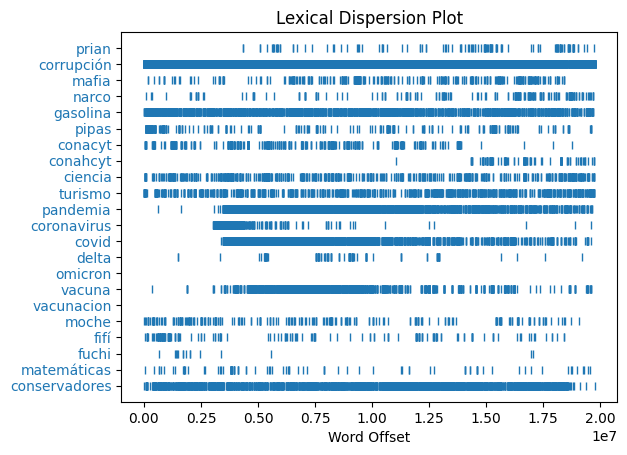

In [24]:
# Ordenamos los archivos por fecha.
files_sorted = sorted([f for f in files if extraer_fecha(f) is not None], key = extraer_fecha)

# Leemos el contenido de los archivos y los concatenamos en un solo string.
all_text = "" # String vacío para almacenar el contenido de los archivos.
for file in files_sorted:
    with open(file, "r", encoding = "utf-8") as f:
        all_text += f.read()

# Tokenización con TweetTokenizer.
tweet_tokenizer = TweetTokenizer()                  # Creamos un objeto TweetTokenizer de NLTK.
tokens = tweet_tokenizer.tokenize(all_text.lower()) # Preferí usar minúsculas para evitar duplicados.
text_nltk = Text(tokens)                            # Creamos un objeto Text de NLTK.
                                                    # Se trabajará siempre con este objeto a partir de ahora.

# Palabras clave.
palabras_clave = [
    "prian", "corrupción", "mafia", "narco", "gasolina", "pipas", "conacyt", "conahcyt", "ciencia",
    "turismo", "pandemia", "coronavirus", "covid", "delta", "omicron", "vacuna", "vacunacion",
    "moche", "fifí", "fuchi", "matemáticas", "conservadores" # Estas son las que elegí yo.
]

# Grafico de dispersión.
text_nltk.dispersion_plot(palabras_clave)

### **3.4.- Muestre 50 colocaciones de todo el corpus.**

In [25]:
# Calcular y mostrar las 50 colocaciones más frecuentes
print("50 colocaciones en el corpus:\n")
text_nltk.collocations(num = 50)

50 colocaciones en el corpus:

lópez obrador; andrés manuel; manuel lópez; presidente andrés; estados
unidos; por ciento; buenos días; versión estenográfica; señor
presidente; todos los; nada más; prensa matutina; claudia sheinbaum;
guardia nacional; sheinbaum pardo; muchas gracias; por eso; por
ejemplo; tren maya; desde luego; sin embargo; poder judicial; redes
sociales; creo que; baja california; ramírez cuevas; quintana roo; mil
millones; muy importante; derechos humanos; sobre todo; jesús ramírez;
todas las; por qué; muy bien; último grito; que que; matutina del;
nuestro país; adultos mayores; marcelo ebrard; ver con; tiene que;
cuarta transformación; para que; garcía luna; los mexicanos; los
trabajadores; comisión federal; del estado


### **3.5.- Muestre un histograma de longitud en caracteres de las palabras. Muestre en el histograma el top 5 de longitudes más largas.**

Distribución de frecuencias:
 <FreqDist with 50 samples and 19756316 outcomes>
Top 5 de longitudes más largas con su frecuencia:
Longitud 86: 1 veces
Longitud 81: 1 veces
Longitud 69: 1 veces
Longitud 68: 7 veces
Longitud 54: 1 veces


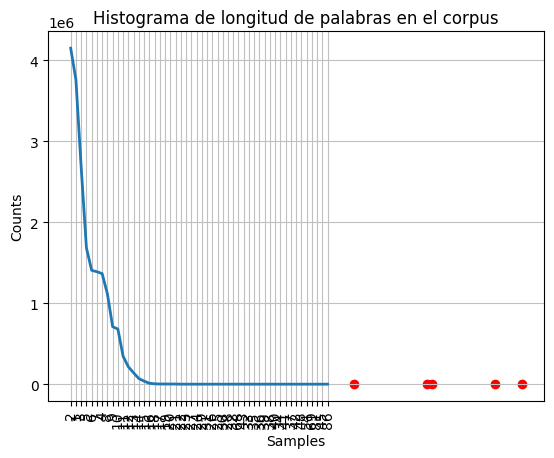

In [26]:
setOFLenghts = [len(w) for w in text_nltk]  # Obtenemos la longitud de cada palabra en el corpus
fdist = FreqDist(setOFLenghts)
              # Calculamos la frecuencia de cada longitud.
print("Distribución de frecuencias:\n", fdist) # Mostramos la distribución de frecuencias.

# Obtener las 5 longitudes más largas.
top_5_lengths = sorted(fdist.keys(), reverse = True)[:5]

# Mostramos el top 5 de longitudes más largas con su frecuencia.
print("Top 5 de longitudes más largas con su frecuencia:")
for length in top_5_lengths:
    print(f"Longitud {length}: {fdist[length]} veces")

# Graficar el histograma de las longitudes de palabras en el corpus.
fdist.plot(max(top_5_lengths), cumulative = False, title = "Histograma de longitud de palabras en el corpus")

# Resaltar las 5 longitudes más largas en rojo
for length in top_5_lengths:
    plt.scatter(length, fdist[length], color = 'red')

### **3.6.- Muestre 50 palabras con longitud mayor a 8 caracteres y frecuencia mayor a 5 en todo el texto usando comprenhension list de python.**

In [27]:
# Calcular la frecuencia de cada palabra en el corpus
fdist_words = FreqDist(text_nltk)

# Filtrar palabras con longitud > 8 y frecuencia > 5 usando list comprehension
filtered_words = [word for word in fdist_words if len(word) > 8 and fdist_words[word] > 5]

# Tomar las primeras 50 palabras que cumplen la condición
filtered_words_top50 = filtered_words[:50]

# Mostrar las palabras y sus frecuencias sin usar pandas
print("🔍 50 palabras con longitud > 8 y frecuencia > 5:")
print("-" * 50)
for word in filtered_words_top50:
    print(f"{word}: {fdist_words[word]}")

🔍 50 palabras con longitud > 8 y frecuencia > 5:
--------------------------------------------------
presidente: 110575
importante: 16463
seguridad: 15603
información: 13911
interlocutor: 13805
interlocutora: 13253
secretaría: 12705
corrupción: 11508
conferencia: 11128
mexicanos: 9740
presidenta: 8976
trabajadores: 8700
secretario: 8519
estenográfica: 7410
intervención: 6996
bienestar: 6937
trabajando: 6605
presupuesto: 6503
situación: 6436
investigación: 6179
república: 6127
elementos: 6094
transformación: 6008
preguntarle: 5921
construcción: 5854
violencia: 5706
desarrollo: 5652
población: 5297
gobernador: 5273
comunicación: 5100
inversión: 5076
sheinbaum: 5026
siguiente: 5008
aeropuerto: 4944
educación: 4931
protección: 4664
municipios: 4571
precisamente: 4430
democracia: 4407
hospitales: 4393
secretaria: 4365
solamente: 4321
administración: 4268
independencia: 4263
autoridades: 4240
instituto: 4135
constitución: 4101
gobiernos: 4045
participación: 3968
imagínense: 3968


### **3.7.- Ver https://www.nltk.org/book/ch02.html en la sección 1.5. Proponga una gráfica usando ConditionalFreqDist como la de la Sección 1.5 para estos datos. Usted elige las palabras.**

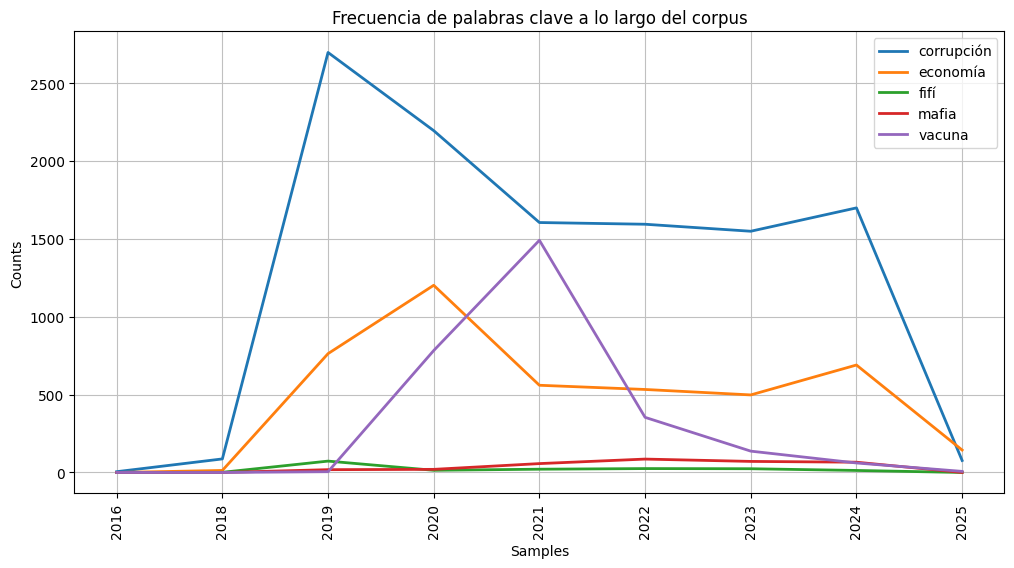

In [28]:
from nltk.probability import ConditionalFreqDist # Cargar ConditionalFreqDist de NLTK.

# Palabras clave que queremos analizar en el tiempo
palabras_clave = ["corrupción", "fifí", "mafia", "vacuna", "economía"]

# Creamos un objeto ConditionalFreqDist:
cfd = ConditionalFreqDist(
    (word, extraer_fecha(file).year)
    for file in files_sorted
    for word in tweet_tokenizer.tokenize(open(file, "r", encoding = "utf-8").read().lower())
    if word in palabras_clave
)

# Graficamos la frecuencia de las palabras clave a lo largo del tiempo.
plt.figure(figsize = (12,6))
cfd.plot(title="Frecuencia de palabras clave a lo largo del corpus")
plt.show()

### **3.8.- Use la lista de stopwords de nltk y obtenga la cantidad de palabras en los datos con y sin stopword. Comente brevemente las diferencias.**

In [29]:
# Descargamos y cargamos la lista de stopwords de NLTK.
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Uso de stopwords en español
stopwords_es = set(stopwords.words("spanish")) # Obtener lista de stopwords en español
total_palabras = len(text_nltk)                # Contar la cantidad total de palabras en el corpus

# Filtrar palabras quitando las stopwords
palabras_sin_stopwords = [word for word in text_nltk if word.lower() not in stopwords_es]
total_sin_stopwords = len(palabras_sin_stopwords)

# Mostrar resultados
diferencia = total_palabras - total_sin_stopwords
print("\nResultados de palabras con y sin stopwords:")
print("-" * 50)
print(f"Total de palabras en el corpus             : {total_palabras}")
print(f"Total de palabras sin stopwords            : {total_sin_stopwords}")
print(f"Reducción de palabras al eliminar stopwords: {diferencia} ({diferencia / total_palabras * 100:.2f}%)")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ezautorres/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Resultados de palabras con y sin stopwords:
--------------------------------------------------
Total de palabras en el corpus             : 19756316
Total de palabras sin stopwords            : 11126801
Reducción de palabras al eliminar stopwords: 8629515 (43.68%)


### **3.9.- Muestre las 300 palabras más frecuentes en las conferencias, sin tomar en cuenta stop-words. Muéstrelas de la más frecuente a la menos frecuente.**

In [30]:
# Calculamos la frecuencia de cada palabra en el corpus sin stopwords
fdist_sin_stopwords = FreqDist(word for word in text_nltk if word.lower() not in stopwords_es)

# Obtenemos las 300 palabras más comunes sin stopwords.
top_300_palabras = fdist_sin_stopwords.most_common(300)

# Visualizamos las 300 palabras más comunes sin stopwords.
for palabra, frecuencia in top_300_palabras:
    print(f"{palabra}: {frecuencia}")

,: 1584699
.: 659125
:: 157939
presidente: 110575
¿: 84027
?: 83835
lópez: 60383
obrador: 58848
manuel: 58763
andrés: 57902
si: 57153
entonces: 53212
;: 52874
méxico: 48699
vamos: 48510
va: 48373
mil: 46556
aquí: 33659
gobierno: 31573
pues: 28935
ver: 27966
‘: 27944
ahora: 27241
dos: 26866
’: 26737
bueno: 25125
ahí: 24855
caso: 23811
…: 23684
millones: 23445
cómo: 22946
pregunta: 22944
país: 21971
pueblo: 21794
nacional: 21379
pesos: 21200
días: 20872
así: 20687
van: 20648
ser: 20611
hacer: 20061
usted: 19878
ciento: 19427
gente: 19369
señor: 18760
gracias: 17895
-: 17746
tema: 17348
bien: 17189
parte: 16896
años: 16821
tres: 16720
año: 16671
—: 16580
importante: 16463
decir: 16246
poder: 16111
hoy: 16006
puede: 15743
todas: 15709
seguridad: 15603
día: 15549
salud: 15379
hace: 15257
unidos: 15218
manera: 15176
tener: 15138
personas: 15111
mismo: 15003
prensa: 14994
general: 14550
tiempo: 14507
información: 13911
buenos: 13852
interlocutor: 13805
interlocutora: 13253
además: 13245
luego

# **4.- OTRAS LIBRERÍAS EN PYTHON (20pts)**

Investigue y comente brevemente en sus propias palabras:

### **4.1.- Mencione dos librerías en Python además de NLTK para NLP. Ponga una desventaja y ventaja de cada una.**

>1. **spaCy:**
>
>Es una librería moderna para procesamiento de lenguaje natural optimizada para velocidad y eficiencia.
>
>- Ventajas: Es rápida y eficiente, especialmente para procesamiento de texto en grandes volúmenes e incluye modelos preentrenados para tareas como etiquetado POS, análisis de dependencias y reconocimiento de entidades.
>
>- Desventaja: Es menos flexible que NLTK para algunas tareas lingüísticas más especializadas y no tiene tantas herramientas para procesamiento de texto más académico y detallado como NLTK.
>
>2. **Transformers (de Hugging Face):**
>
>Es una librería especializada en modelos de deep learning para NLP, incluyendo modelos como BERT, GPT, T5, etc.
>
>- Ventaja: Es capaz de manejar tareas complejas de NLP como traducción, resúmenes, análisis de sentimientos y más con modelos preentrenados. Además, cuenta con fácil integración con PyTorch y TensorFlow, lo que permite usar modelos avanzados con pocas líneas de código.
>
>- Desventaja: Es computacionalmente costosa, requiere GPU para aprovechar al máximo los modelos y no es ideal para tareas básicas de procesamiento de texto (tokenización simple, stemming, etc.), donde NLTK o spaCy son más eficientes.
>
>**Así que:**
>
>Si se necesita procesamiento rápido y eficiente en grandes volúmenes de texto, se debería usar spaCy y si se tranaja con modelos avanzados de deep learning para NLP, hay que usar Transformers de Hugging Face.

### **4.2.- Mencione tres alternativas para Text Processing en NLP qué existen en otros lenguajes. De una ventaja y desventaja de cada una.**

>1. **Stanford NLP (Java)**
>
>Es una herramienta desarrollada por la Universidad de Stanford, basada en Java, con soporte para múltiples tareas NLP como tokenización, POS tagging, parsing, NER y coreference resolution.
>
>- Ventaja: Cuenta con alta precisión en tareas como análisis sintáctico y NER debido a modelos estadísticos avanzados y soporta múltiples idiomas y se puede usar con Python a través de stanza.
>
>- Desventaja: es lenta y pesada, especialmente cuando se usa en grandes volúmenes de datos. Además requiere configuración avanzada en entornos de producción.
>
>2. **Apache OpenNLP (Java)**
>
>Es un toolkit de NLP basado en Java, desarrollado por Apache, diseñado para procesamiento eficiente en sistemas empresariales.
>
>- Ventaja: Optimizado para escalabilidad, ideal para procesamiento en grandes volúmenes de texto. Fácil integración con otras herramientas de Apache como Spark y Hadoop.
>
>- Desventaja: Menos modelos preentrenados en comparación con spaCy o Transformers. Menor comunidad y documentación que alternativas como NLTK o Stanford NLP.
>
>3. **FastText (C++)**
>
>Es una biblioteca desarrollada por Facebook AI para procesamiento rápido de texto y aprendizaje de representaciones de palabras en C++.
>
>- Ventaja: Extremadamente rápida y eficiente, ideal para clasificación de texto y embeddings de palabras. Soporta aprendizaje de embeddings sub-palabra, útil en idiomas con alta morfología (ej. turco, alemán).
>
>- Desventaja: Menos flexible para NLP general que otras herramientas como spaCy o NLTK. Mayor dificultad de implementación, ya que está en C++ y requiere compilación para integrarse con otros lenguajes.

# **5.- PUNTOS EXTRA EN TAREAS (40pts), valor máximo de la tarea 140%**

Hacer la tarea incluyendo las mañaneras de la presidenta: https://www.gob.mx/presidencia/es/#14882 y Mencione al PRINCIPIO del notebook de tarea si incluyo esta información o no.

>¡Listo!